In [1]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [16]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json

In [17]:
#NB: `search_images` depends on duckduckgo.com, which doesn't always return correct responses.
#    If you get a JSON error, just try running it again (it may take a couple of tries).
urls = search_images('bird photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg'

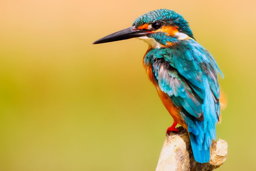

In [18]:
from fastdownload import download_url
dest = 'bird.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

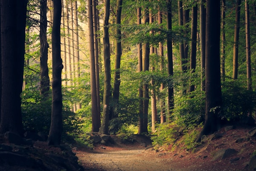

In [19]:
forest_url = 'https://images.unsplash.com/photo-1441974231531-c6227db76b6e?w=600'

download_url(forest_url, 'forest.jpg', show_progress=False)
img = Image.open('forest.jpg')
img.to_thumb(256,256)

In [20]:
from icrawler.builtin import BingImageCrawler

searches = 'forest', 'bird'
path = Path('bird_or_not')

for o in searches:
    dest = path / o
    dest.mkdir(exist_ok=True, parents=True)
    crawler = BingImageCrawler(storage={'root_dir': str(dest)})
    crawler.crawl(keyword=f'{o} photo', max_num=200)

2026-06-29 15:55:18,809 - INFO - icrawler.crawler - start crawling...
2026-06-29 15:55:18,809 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-06-29 15:55:18,810 - INFO - icrawler.crawler - starting 1 parser threads...
2026-06-29 15:55:18,810 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-06-29 15:55:19,067 - INFO - parser - parsing result page https://www.bing.com/images/async?q=forest photo&first=0
2026-06-29 15:55:19,213 - INFO - parser - parsing result page https://www.bing.com/images/async?q=forest photo&first=20
2026-06-29 15:55:19,398 - INFO - parser - parsing result page https://www.bing.com/images/async?q=forest photo&first=40
2026-06-29 15:55:19,542 - INFO - parser - parsing result page https://www.bing.com/images/async?q=forest photo&first=60
2026-06-29 15:55:19,544 - INFO - feeder - thread feeder-001 exit
2026-06-29 15:55:19,656 - INFO - downloader - image #1	https://i.pinimg.com/736x/6a/f7/a2/6af7a24e3622c099e3e1edfdb6f5d125.jpg
2026-06-29 1

In [21]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid 

0

/home/ojke/ML-Learning/.venv312/lib/python3.12/site-packages/matplotlib/cbook.py:713: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/home/ojke/ML-Learning/.venv312/lib/python3.12/site-packages/matplotlib/cbook.py:713: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/home/ojke/ML-Learning/.venv312/lib/python3.12/site-packages/matplotlib/cbook.py:713: DeprecationWarning: __array__ implementation doesn

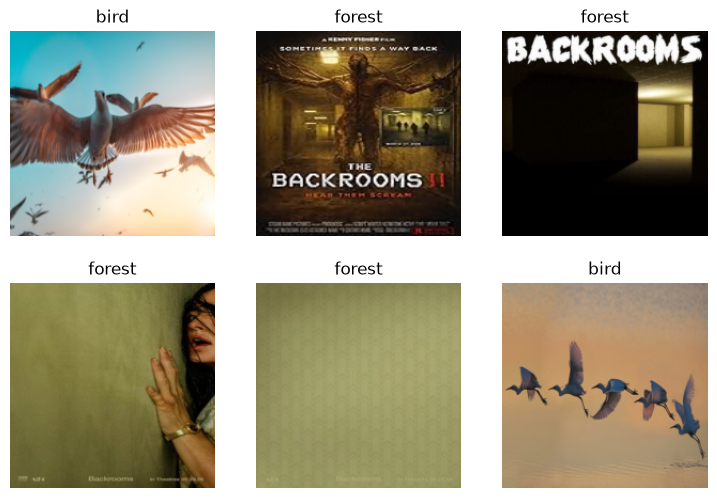

In [22]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [35]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.956737,2.598818,0.500000,00:00


/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid 

epoch,train_loss,valid_loss,error_rate,time
0,0.903348,1.860843,0.500000,00:00
1,0.718469,1.414628,0.500000,00:00
2,0.599806,1.010136,0.333333,00:00


/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ojke/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=44921) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid 

In [36]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

This is a: bird.
Probability it's a bird: 1.0000
